In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error,root_mean_squared_error
from sklearn.datasets import fetch_california_housing

In [3]:
housing = fetch_california_housing()
data = fetch_california_housing(as_frame=True).frame

In [4]:
data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [6]:
data.shape

(20640, 9)

In [7]:
print("Missing values:\n",data.isnull().sum())

Missing values:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [8]:
print("Duplicate Values:\n",data.duplicated().sum())

Duplicate Values:
 0


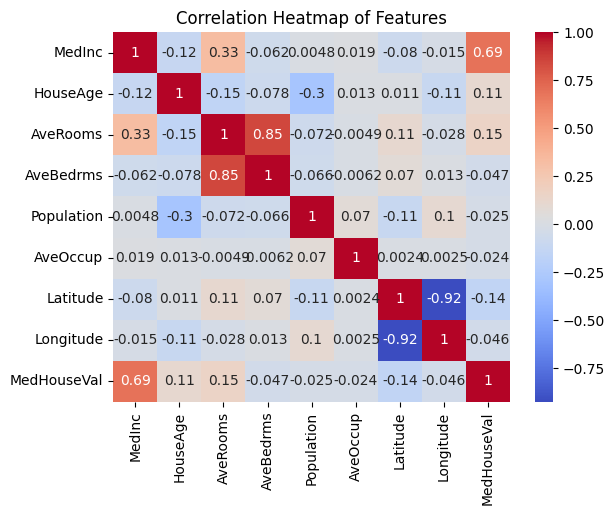

In [9]:
plt.Figure(figsize=(10,6))
sns.heatmap(data.corr(),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap of Features')
plt.show()

In [10]:
x=data.drop("MedHouseVal",axis=1)
y=data['MedHouseVal']

In [11]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [12]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [13]:
print(x_train_scaled.shape)
print(x_test_scaled.shape)

(16512, 8)
(4128, 8)


In [15]:
print(x_train_scaled)

[[-0.326196    0.34849025 -0.17491646 ...  0.05137609 -1.3728112
   1.27258656]
 [-0.03584338  1.61811813 -0.40283542 ... -0.11736222 -0.87669601
   0.70916212]
 [ 0.14470145 -1.95271028  0.08821601 ... -0.03227969 -0.46014647
  -0.44760309]
 ...
 [-0.49697313  0.58654547 -0.60675918 ...  0.02030568 -0.75500738
   0.59946887]
 [ 0.96545045 -1.07984112  0.40217517 ...  0.00707608  0.90651045
  -1.18553953]
 [-0.68544764  1.85617335 -0.85144571 ... -0.08535429  0.99543676
  -1.41489815]]


In [16]:
model=LinearRegression()
model.fit(x_train_scaled,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [44]:
y_pred=model.predict(x_test_scaled)

In [46]:
lr_mae = mean_absolute_error(y_test, y_pred )
lr_mse=mean_squared_error(y_test,y_pred)
lr_r2=r2_score(y_test,y_pred)

In [47]:
print("\nIntercept:", model.intercept_)
print("Coefficients:", model.coef_)
print("Mean Absolute Error:", lr_mae)
print("Mean Squared Error:", lr_mse)
print("R² Score:", lr_r2)


Intercept: 2.0719469373788777
Coefficients: [ 0.85438303  0.12254624 -0.29441013  0.33925949 -0.00230772 -0.0408291
 -0.89692888 -0.86984178]
Mean Absolute Error: 0.5332001304956565
Mean Squared Error: 0.5558915986952442
R² Score: 0.575787706032451


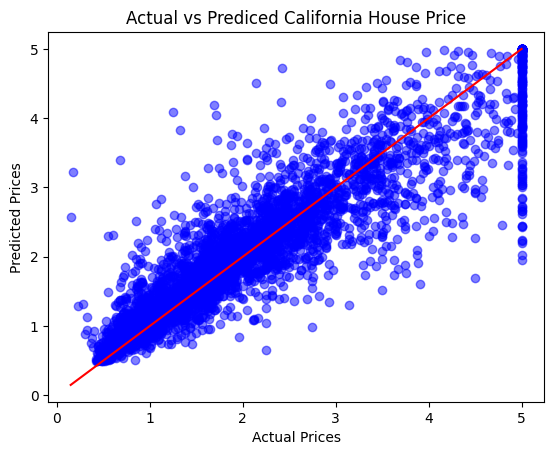

In [33]:
plt.scatter(y_test,y_pred,color="blue",alpha=0.5)
plt.plot([min(y_test),max(y_test)] , [min(y_test),max(y_test)] , color='red')
plt.title("Actual vs Prediced California House Price")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.show()

In [23]:
rf_model = RandomForestRegressor(n_estimators=100,random_state=42)

In [27]:
rf_model.fit(x_train_scaled, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
rf_y_pred = rf_model.predict(x_test_scaled)
print(rf_y_pred)

[0.5095    0.74161   4.9232571 ... 4.7582187 0.71379   1.65772  ]


In [36]:
rf_mae = mean_absolute_error(y_test, rf_y_pred )
rf_mse = mean_squared_error(y_test, rf_y_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_y_pred)

In [37]:
print("Mean Absolute Error:", rf_mae)
print("Mean Squared Error:", rf_mse)
print("Root Mean Squared Error:", rf_rmse)
print("R2 Score:", rf_r2)

Mean Absolute Error: 0.3274252027374032
Mean Squared Error: 0.255169737347244
Root Mean Squared Error: 0.5051432839771741
R2 Score: 0.8052747336256919


In [48]:
comparison = pd.DataFrame({"Model" : ["LinearRegression","RandomForestRegressor"],
                           "MAE":[lr_mae,rf_mae],
                           "MSE ":[lr_mse,rf_mse],
                           "R2 Score":[lr_r2,rf_r2]})
print(comparison)

                   Model       MAE      MSE   R2 Score
0       LinearRegression  0.533200  0.555892  0.575788
1  RandomForestRegressor  0.327425  0.255170  0.805275


In [51]:
xgb_model = XGBRegressor(n_estimator=100,learning_rate=0.1,max_depth=6,random_state=42)

In [52]:
xgb_model.fit(x_train_scaled,y_train)

C:\Users\ADHITHYA\AppData\Roaming\Python\Python310\site-packages\xgboost\training.py:200: UserWarning: [12:35:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [53]:
xgb_y_pred = xgb_model.predict(x_test_scaled)

In [54]:
xgb_mae = mean_absolute_error(y_test,xgb_y_pred)
xgb_mse = mean_squared_error(y_test,xgb_y_pred)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = r2_score(y_test,xgb_y_pred)

In [55]:
print("Mean Absolute Error:",xgb_mae)
print("Mean Squared Error:", xgb_mse)
print("Root Mean Squared Error:", xgb_rmse)
print("R2 Score:", xgb_r2)

Mean Absolute Error: 0.3154509897767458
Mean Squared Error: 0.22726228796011422
Root Mean Squared Error: 0.47672034565362764
R2 Score: 0.8265714813208984


In [56]:
comparison = pd.DataFrame({"Model" : ["LinearRegression","RandomForestRegressor","XGBOOSTRegressor"],
                           "MAE":[lr_mae,rf_mae,xgb_mae],
                           "MSE ":[lr_mse,rf_mse,xgb_mse],
                           "R2 Score":[lr_r2,rf_r2,xgb_r2]})
print(comparison)

                   Model       MAE      MSE   R2 Score
0       LinearRegression  0.533200  0.555892  0.575788
1  RandomForestRegressor  0.327425  0.255170  0.805275
2       XGBOOSTRegressor  0.315451  0.227262  0.826571
